# 실험 데이터셋 4종 EDA — 학습·추가·평가 데이터 전수 분석

> **작성**: 김한솔 · 2026-07-03
> **대상**: 실험①②가 사용하는 파일 4종 전부

| 파일 | 역할 | 규모 | 상세 EDA |
|---|---|---|---|
| `kcelectra_train_clean.jsonl` | 학습 본셋 | 58,234 | ✅ `EDA_감정분류_김한솔.ipynb` (§2에서 요약) |
| `aug_voice.jsonl` | 추가 학습 후보 (실험②) | 36,677 | 본 문서 §3~5 |
| `aug_wellness.jsonl` | 추가 학습 후보 (실험②) | 1,002 | 본 문서 §6~7 |
| `chat_eval_set.jsonl` | **평가 전용** (학습 금지) | 60 | 본 문서 §8 |

## 목차
1. 4종 로드
2. 본셋 요약 (상세는 별도 EDA 참조)
3. 음성 — 컬럼 인벤토리 (15열 전수)와 채택/제외 사유
4. 음성 — 합의도·'상황' 컬럼 검증·정제 전후
5. 웰니스 — 컬럼 인벤토리 (3열)와 카테고리 매핑 커버리지
6. 웰니스 — (§7과 통합)
7. chat_eval — 평가셋 설계 명세와 한계
8. **4종 통합 비교** — 규모·라벨 분포·길이·문체
9. 결론 — 컬럼·행 제외 사유 총괄
> **보강 (2026-07-05)**: §5 KOTE(5번째 데이터) 원천→매핑 EDA, §6 최종 학습셋(90,456) 통합 분포 추가 — 이 노트북 하나로 학습에 쓴 데이터 전부를 설명한다.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, re, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter

for f in fm.fontManager.ttflist:
    if 'Nanum' in f.name or 'CJK' in f.name:
        plt.rcParams['font.family'] = f.name
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', 70)

# 정제본 4종 (repo data/)
DATA_CANDIDATES = [r'..\..\data', '../../data']
DATA = next((p for p in DATA_CANDIDATES if os.path.isdir(p)), '../../data')

def load_jsonl(name):
    path = os.path.join(DATA, name)
    return pd.DataFrame([json.loads(l) for l in open(path, encoding='utf-8') if l.strip()])

base = load_jsonl('kcelectra_train_clean.jsonl')
aug_v = load_jsonl('aug_voice.jsonl')
aug_w = load_jsonl('aug_wellness.jsonl')
chat = load_jsonl('chat_eval_set.jsonl')

# 원천 (컬럼 분석용 — 없으면 해당 섹션 자동 스킵)
VAULT_CANDIDATES = [
    r'C:\Users\Playdata\Documents\Obsidian Vault\SKN27기 최종프로젝트 - 웰니스 멘탈케어',
    '/sessions/epic-friendly-knuth/mnt/SKN27기 최종프로젝트 - 웰니스 멘탈케어',
]
VAULT = next((p for p in VAULT_CANDIDATES if os.path.isdir(p)), None)
voice_raw = wellness_raw = None
if VAULT:
    vd = os.path.join(VAULT, '감정 분류를 위한 대화 음성 데이터셋')
    voice_raw = pd.concat([pd.read_csv(os.path.join(vd, f), encoding='cp949')
                           for f in ['4차년도.csv', '5차년도.csv', '5차년도_2차.csv']],
                          ignore_index=True)
    wellness_raw = pd.read_excel(os.path.join(
        VAULT, '웰니스 대화 스크립트 데이터셋', '웰니스_대화_스크립트_데이터셋.xlsx'))
print(f'정제본 4종: base {len(base):,} / voice {len(aug_v):,} / wellness {len(aug_w):,} / chat_eval {len(chat)}')
print('원천:', '로드됨' if VAULT else '없음 (컬럼 분석 섹션 스킵)')

정제본 4종: base 58,234 / voice 36,677 / wellness 1,002 / chat_eval 60
원천: 로드됨


## 2. 본셋 요약 — `kcelectra_train_clean.jsonl`

상세 분석(출처·계보 100% 검증·결측·중복·이상치·최빈 단어·신호 토큰)은
**`EDA_감정분류_김한솔.ipynb`** 참조. 여기서는 4종 비교에 필요한 지표만 재계산한다.
- 원천: AI Hub 감성대화 58,268 대화 → HS01+대분류 추출, 6→4 매핑, 중복·상충 34건 제거
- 컬럼 제외: 시스템 응답·후속 턴·페르소나 메타·세부 60감정 (학습 입력 = 서빙 입력 원칙)

In [ ]:
SIX_TO_FOUR = {'기쁨':'기쁨','슬픔':'슬픔','상처':'슬픔','분노':'분노','불안':'분노','당황':'일반'}
base['mode4'] = base['emotion'].map(SIX_TO_FOUR)
print('6감정 원천 라벨:', base['emotion'].value_counts().to_dict())
print('4모드:', base['mode4'].value_counts().to_dict())
print(f"평균 길이 {base['text'].str.len().mean():.1f}자")

6감정 원천 라벨: {'불안': 10427, '분노': 10413, '상처': 10140, '슬픔': 10120, '당황': 9797, '기쁨': 7337}
4모드: {'분노': 20840, '슬픔': 20260, '일반': 9797, '기쁨': 7337}
평균 길이 35.3자


## 3. 음성 — 컬럼 인벤토리 (15열 전수)

| 컬럼 | 내용 | 판정 | 사유 |
|---|---|---|---|
| `wav_id` | 음성 파일 키 | ❌ 제외 | 텍스트 분류 — 음성 파일 자체를 안 씀 |
| `발화문` | 발화 텍스트 | ✅ **채택 (입력)** | 학습 입력 = 서빙 입력(사용자 문장) |
| `상황` | 녹음 시 지시된 연기 상황 | ❌ 제외 | §4에서 실증 — "지시"이지 "판정"이 아님 |
| `1~5번 감정` | 어노테이터 5명의 감정 판정 | ✅ **채택 (라벨)** | 다수결(3표+)로 라벨 확정 |
| `1~5번 감정세기` | 각 판정의 강도(0~2) | ❌ 제외 | 4모드 분류엔 유/무만 필요 — 세기는 회귀 문제화, 서비스 요구사항에 없음 |
| `나이`, `성별` | 화자 메타 | ❌ 제외 | 서빙 시점에 알 수 없음 (본셋과 동일 원칙) — 편향 점검용으로만 §4에서 확인 |

In [ ]:
if voice_raw is not None:
    print('컬럼:', list(voice_raw.columns))
    display(voice_raw.head(3))
    print('결측:', '없음' if not voice_raw.isna().any().any()
          else voice_raw.isna().sum()[voice_raw.isna().sum() > 0].to_dict())
    print(f"발화문 중복: {voice_raw['발화문'].duplicated().sum():,}건")

컬럼: ['wav_id', '발화문', '상황', '1번 감정', '1번 감정세기', '2번 감정', '2번 감정세기', '3번 감정', '3번 감정세기', '4번 감정', '4번감정세기', '5번 감정', '5번 감정세기', '나이', '성별']


,wav_id,발화문,상황,1번 감정,1번 감정세기,2번 감정,2번 감정세기,3번 감정,3번 감정세기,4번 감정,4번감정세기,5번 감정,5번 감정세기,나이,성별
0,5e258fd1305bcf3ad153a6a4,"어, 청소 니가 대신 해 줘!",anger,Neutral,0,Angry,1,Neutral,0,Neutral,0,Angry,1,27,male
1,5e258fe2305bcf3ad153a6a5,둘 다 청소 하기 싫어. 귀찮아.,anger,Neutral,0,Angry,1,Neutral,0,Neutral,0,Angry,1,27,male
2,5e258ff5305bcf3ad153a6a6,둘 다 하기 싫어서 화내.,anger,Angry,1,Angry,1,Neutral,0,Angry,1,Angry,1,27,male


결측: 없음
발화문 중복: 6,779건


## 4. 음성 — 합의도 · '상황' 검증 · 정제 전후

**4-1. "3표 이상" 기준의 근거**: 5명이 같은 발화를 판정 — 몇 명이 일치하는지가 라벨 신뢰도.

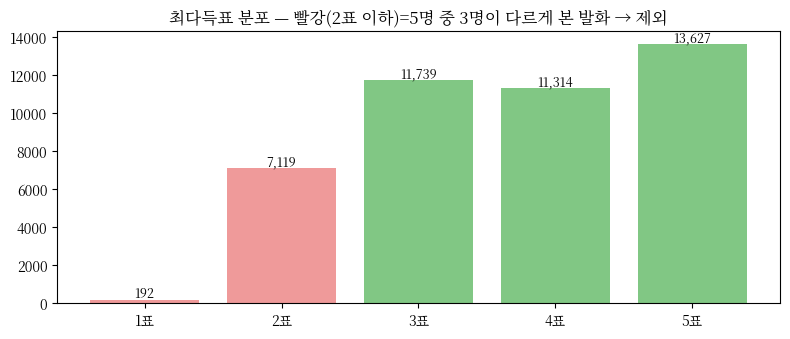

과반 합의 36,680 채택 / 미달 7,311(16.6%) 제외
[합의 미달 예시 — 실제로 애매한지 눈검증]


,발화문,상황,1번 감정,2번 감정,3번 감정,4번 감정,5번 감정
15,응. 혼 났지.,sad,Angry,Neutral,Sadness,Sadness,Neutral
22,일주일에 다섯번은 먹는다니까?,anger,Neutral,Surprise,Angry,Angry,Surprise
49,우리는 싸울 일이 전혀 없었어.,sad,Sadness,Neutral,Neutral,Sadness,Angry
57,어제 지진 난 거 알아?,fear,Surprise,Surprise,Fear,Neutral,Neutral


In [ ]:
if voice_raw is not None:
    EMO_COLS = ['1번 감정', '2번 감정', '3번 감정', '4번 감정', '5번 감정']
    tv = voice_raw.apply(lambda r: Counter(
        str(r[k]).strip().lower() for k in EMO_COLS if str(r[k]).strip()).most_common(1)[0], axis=1)
    voice_raw['maj_label'] = tv.str[0]
    voice_raw['maj_votes'] = tv.str[1]

    dist = voice_raw['maj_votes'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.bar(dist.index.astype(str) + '표', dist.values,
           color=['#EF9A9A' if v < 3 else '#81C784' for v in dist.index])
    for i, v in enumerate(dist.values):
        ax.text(i, v + 150, f'{v:,}', ha='center', fontsize=9)
    ax.set_title('최다득표 분포 — 빨강(2표 이하)=5명 중 3명이 다르게 본 발화 → 제외')
    plt.tight_layout(); plt.show()
    drop = (voice_raw['maj_votes'] < 3).sum()
    print(f'과반 합의 {(voice_raw.maj_votes >= 3).sum():,} 채택 / 미달 {drop:,}({drop/len(voice_raw)*100:.1f}%) 제외')
    print('[합의 미달 예시 — 실제로 애매한지 눈검증]')
    display(voice_raw[voice_raw.maj_votes < 3][['발화문', '상황'] + EMO_COLS].head(4))

**4-2. '상황' 컬럼을 라벨로 안 쓴 이유 — 실증**: `상황`은 지시("anger 상황으로 말하세요"),
투표는 결과 판정. 지시대로 연기됐다면 둘이 일치해야 한다.

지시(상황) = 판정(다수결) 일치율: 68.1% → 1/3은 지시대로 연기 안 됨


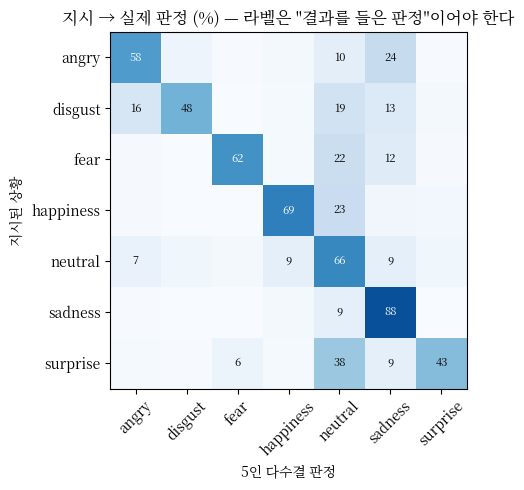

In [ ]:
if voice_raw is not None:
    NORM = {'angry':'angry','anger':'angry','sad':'sadness','sadness':'sadness',
            'happiness':'happiness','neutral':'neutral','disgust':'disgust',
            'fear':'fear','surprise':'surprise'}
    voice_raw['sit_norm'] = voice_raw['상황'].astype(str).str.strip().str.lower().map(NORM)
    agree = (voice_raw['sit_norm'] == voice_raw['maj_label']).mean()
    print(f'지시(상황) = 판정(다수결) 일치율: {agree*100:.1f}% → 1/3은 지시대로 연기 안 됨')

    ct = pd.crosstab(voice_raw['sit_norm'], voice_raw['maj_label'], normalize='index') * 100
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(ct.values, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(ct.columns)), ct.columns, rotation=45)
    ax.set_yticks(range(len(ct.index)), ct.index)
    for i in range(len(ct.index)):
        for j in range(len(ct.columns)):
            v = ct.values[i, j]
            if v >= 5:
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        color='white' if v > 50 else 'black', fontsize=8)
    ax.set_xlabel('5인 다수결 판정'); ax.set_ylabel('지시된 상황')
    ax.set_title('지시 → 실제 판정 (%) — 라벨은 "결과를 들은 판정"이어야 한다')
    plt.tight_layout(); plt.show()

**4-3. 정제 후 산출물(aug_voice) 확인 + 화자 편향 점검**

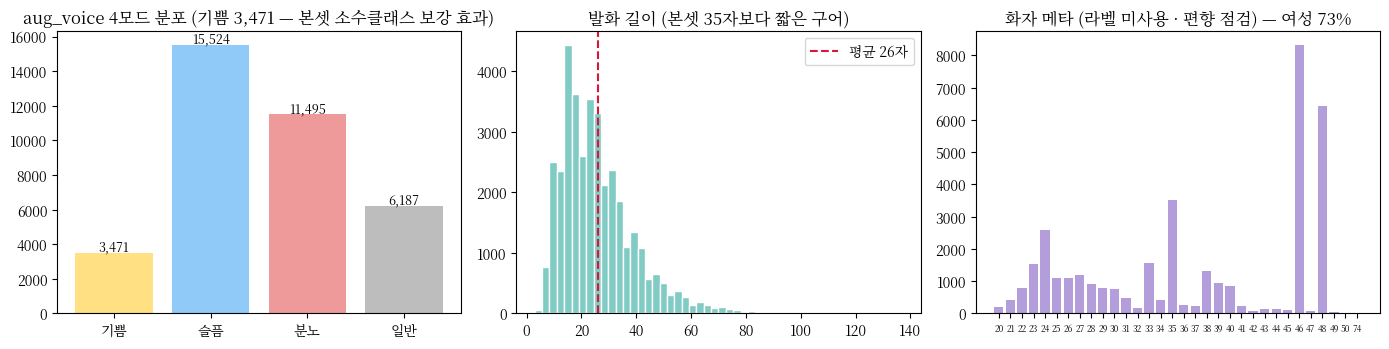

In [ ]:
aug_v['len'] = aug_v['text'].str.len()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
d = aug_v['emotion'].value_counts().reindex(['기쁨', '슬픔', '분노', '일반'])
axes[0].bar(d.index, d.values, color=['#FFE082', '#90CAF9', '#EF9A9A', '#BDBDBD'])
for i, v in enumerate(d.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontsize=9)
axes[0].set_title('aug_voice 4모드 분포 (기쁨 3,471 — 본셋 소수클래스 보강 효과)')
axes[1].hist(aug_v['len'], bins=50, color='#80CBC4', edgecolor='white')
axes[1].axvline(aug_v['len'].mean(), color='crimson', ls='--',
                label=f"평균 {aug_v['len'].mean():.0f}자")
axes[1].legend(); axes[1].set_title('발화 길이 (본셋 35자보다 짧은 구어)')
if voice_raw is not None:
    kept = voice_raw[voice_raw.maj_votes >= 3]
    age = kept['나이'].value_counts().sort_index()
    axes[2].bar(age.index.astype(str), age.values, color='#B39DDB')
    axes[2].set_title(f"화자 메타 (라벨 미사용 · 편향 점검) — 여성 {kept['성별'].eq('female').mean()*100:.0f}%")
    axes[2].tick_params(axis='x', labelsize=6)
plt.tight_layout(); plt.show()

## 5. 웰니스 — 컬럼 인벤토리 (3열 전수)

| 컬럼 | 내용 | 판정 | 사유 |
|---|---|---|---|
| `구분` | 상담 카테고리 (감정/우울감, 증상/불면 등) | ✅ **채택 (라벨 소스)** | `감정/*` 하위명만 4모드 매핑 |
| `유저` | 내담자 발화 | ✅ **채택 (입력)** | 학습 입력 = 사용자 문장 |
| `챗봇` | 상담봇 응답 | ❌ 제외 | 우리 응답은 LLM 생성 — 2020년 상담체 응답 불필요, 감정 라벨도 아님 |

컬럼: ['구분', '유저', '챗봇']


,구분,유저,챗봇
0,감정/감정조절이상,제 감정이 이상해진 것 같아요. 남편만 보면 화가 치밀어 오르고 감정 조절이 안되요.,감정이 조절이 안 될 때만큼 힘들 때는 없는 거 같아요.
1,감정/감정조절이상,더 이상 내 감정을 내가 컨트롤 못 하겠어.,저도 그 기분 이해해요. 많이 힘드시죠?
2,감정/감정조절이상,하루종일 오르락내리락 롤러코스터 타는 기분이에요.,"그럴 때는 밥은 잘 먹었는지, 잠은 잘 잤는지 체크해보는 것도 좋아요."


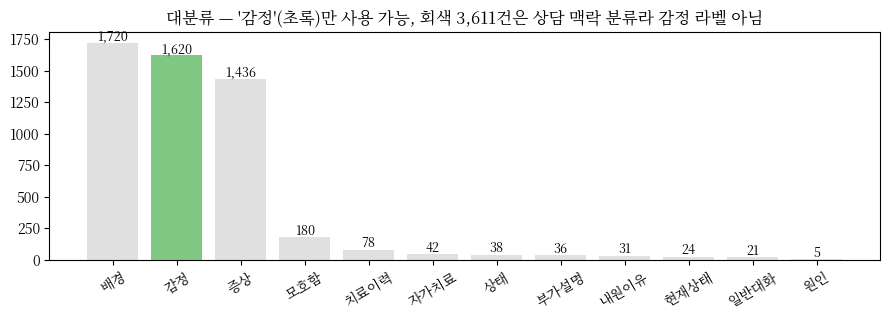

감정/* 1,620 중 매핑 1,002 / 미매핑 618
  (a) 본질적 모호: {'부정적사고': 93, '심란': 34, '생각': 30, '모호함': 19, '신경쓰임': 17, '기분저하': 16}
  (b) 보수적 제외(규칙 확장 시 +200~300건 회수 가능): {'자괴감': 27, '무서움': 24, '서운함': 20, '충격': 19, '불쾌감': 18, '절망감': 18}


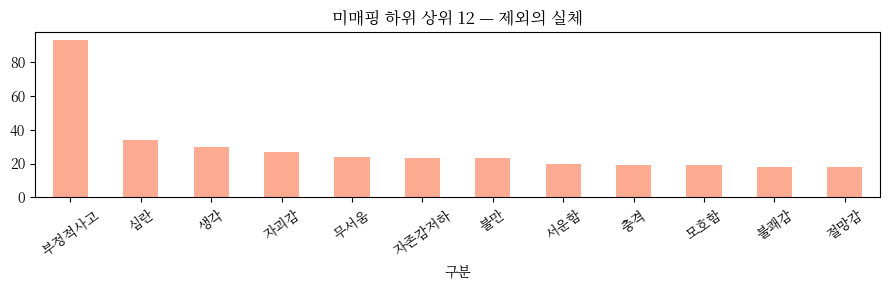

aug_wellness 최종: 1,002건 / 분포 {'슬픔': 505, '분노': 485, '기쁨': 12} ⚠ 기쁨 극소


In [ ]:
if wellness_raw is not None:
    print('컬럼:', list(wellness_raw.columns))
    display(wellness_raw.head(3))
    big = wellness_raw['구분'].astype(str).str.split('/').str[0].value_counts()
    fig, ax = plt.subplots(figsize=(9, 3.3))
    ax.bar(big.index, big.values,
           color=['#81C784' if c == '감정' else '#E0E0E0' for c in big.index])
    for i, v in enumerate(big.values):
        ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=9)
    ax.set_title("대분류 — '감정'(초록)만 사용 가능, 회색 3,611건은 상담 맥락 분류라 감정 라벨 아님")
    plt.xticks(rotation=30); plt.tight_layout(); plt.show()

    RULES = [('기쁨', ['기쁨','행복','즐거움','만족','설렘']),
             ('슬픔', ['힘듦','우울','눈물','괴로움','슬픔','외로움','후회','허무','상실',
                      '자살충동','무기력','서러움','그리움','비관']),
             ('분노', ['짜증','화','분노','불안','걱정','억울','스트레스','답답',
                      '두려움','공포','초조'])]
    emo = wellness_raw[wellness_raw['구분'].astype(str).str.startswith('감정')].copy()
    emo['mode4'] = emo['구분'].map(lambda g: next(
        (e for e, kws in RULES if any(k in str(g).split('/', 1)[-1] for k in kws)), None))
    unmapped = emo[emo['mode4'].isna()]['구분'].str.split('/').str[-1].value_counts()
    print(f"감정/* {len(emo):,} 중 매핑 {emo['mode4'].notna().sum():,} / 미매핑 {emo['mode4'].isna().sum()}")
    print('  (a) 본질적 모호:', {k: int(v) for k, v in unmapped.items()
          if k in ('부정적사고','심란','생각','모호함','신경쓰임','기분저하')})
    print('  (b) 보수적 제외(규칙 확장 시 +200~300건 회수 가능):',
          {k: int(v) for k, v in unmapped.items()
           if k in ('자괴감','무서움','절망감','서운함','불쾌감','충격')})
    fig, ax = plt.subplots(figsize=(9, 3))
    unmapped.head(12).plot(kind='bar', ax=ax, color='#FFAB91', rot=35)
    ax.set_title('미매핑 하위 상위 12 — 제외의 실체')
    plt.tight_layout(); plt.show()
print(f"aug_wellness 최종: {len(aug_w):,}건 / 분포 {aug_w['emotion'].value_counts().to_dict()} ⚠ 기쁨 극소")

## 7. chat_eval — 채팅체 평가셋 설계 명세 (60건 · 자체 제작)

**존재 이유**: 학습·테스트 데이터는 전부 2020년 크라우드 작성체 — 실사용 입력(채팅체)과 문체가 다르다.
"작성체 점수가 낮아도 실사용에선 나을 수 있다"는 가설을 판정하려면 **채팅체 시험지**가 따로 필요하다.

**설계 규칙**
- 4감정 × 15문장 균형 (감정별 동일 문항 수 — Macro F1 안정화)
- 실제 채팅 문체: 반말·축약·"ㅋㅋ/ㅠㅠ"·말줄임
- **함정 문항 포함**: 실측 오분류 사례("점심에 김치찌개 먹었어"→anger 오분류 재현용), 초단문("응 ㅋㅋ", "몰라")
- **학습 투입 절대 금지** — 시험지 오염 방지 (실험①② 코드에서 평가에만 사용)

**한계 (정직하게)**
- 라벨은 작성자 1인 초안 → **팀 검수 필수**
- 60건은 판정력 부족: 문항 3개 차이로 F1이 ~0.1 출렁임 → **150건 이상 증량 권장**
- 실험① QUICK에서 실제로 작성체·채팅체 순위 역전 관찰 — 증량 후 재확인 예정

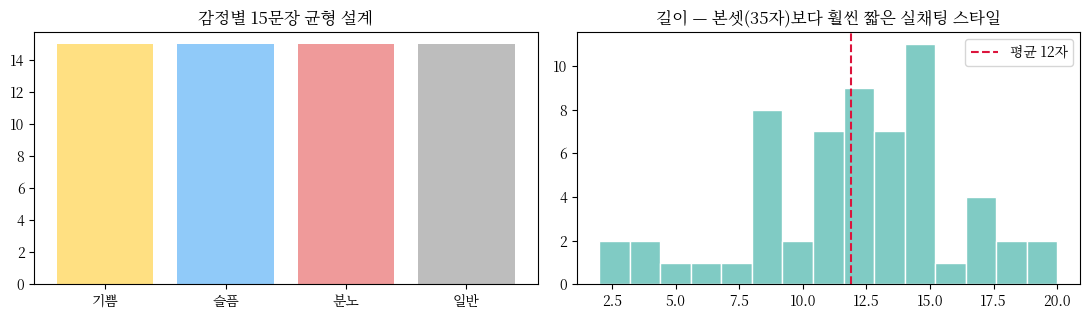

[함정 문항 — 일반 카테고리 예시]
['점심에 김치찌개 먹었어', '응 ㅋㅋ', '몰라', '오늘 날씨 좀 흐리네', '뭐하지', '심심하다', '낼 몇 시에 볼까', '그냥 누워 있어']


In [ ]:
chat['len'] = chat['text'].str.len()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
d = chat['emotion'].value_counts().reindex(['기쁨', '슬픔', '분노', '일반'])
axes[0].bar(d.index, d.values, color=['#FFE082', '#90CAF9', '#EF9A9A', '#BDBDBD'])
axes[0].set_title('감정별 15문장 균형 설계')
axes[1].hist(chat['len'], bins=15, color='#80CBC4', edgecolor='white')
axes[1].axvline(chat['len'].mean(), color='crimson', ls='--', label=f"평균 {chat['len'].mean():.0f}자")
axes[1].legend(); axes[1].set_title('길이 — 본셋(35자)보다 훨씬 짧은 실채팅 스타일')
plt.tight_layout(); plt.show()
print('[함정 문항 — 일반 카테고리 예시]')
print(chat[chat['emotion'] == '일반']['text'].head(8).tolist())

## 8. 4종 통합 비교 — 규모·라벨 분포·길이·문체 한눈에

,규모,평균 길이(자),존댓말(%),기쁨(%),슬픔(%),분노(%),일반(%)
본셋(학습),58234.0,35.3,0.1,12.6,34.8,35.8,16.8
aug_voice(추가),36677.0,25.9,0.5,9.5,42.3,31.3,16.9
aug_wellness(추가),1002.0,25.9,42.8,1.2,50.4,48.4,0.0
chat_eval(평가),60.0,11.9,0.0,25.0,25.0,25.0,25.0


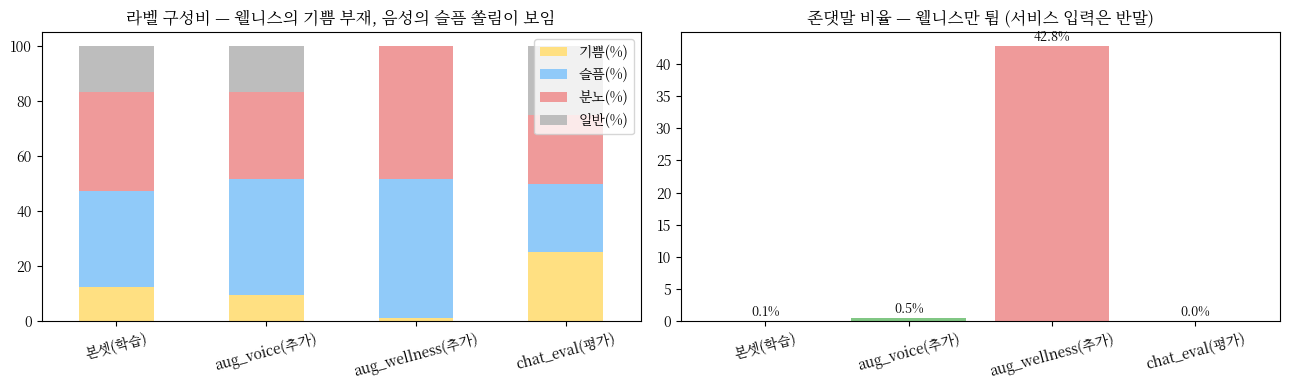

→ 실험② 사전 가설: 웰니스는 ①기쁨 부재 ②문체 상이 — 성능 기여가 어려운 조건 2개를 안고 시작.


In [ ]:
POLITE = re.compile(r'(요|니다|세요|어요|아요|해요|네요|까요|죠)\s*[.!?…~]*\s*$')
def polite_rate(s):
    return s.astype(str).apply(lambda t: bool(POLITE.search(t.strip()))).mean() * 100

sets = {
    '본셋(학습)': base.assign(m=base['mode4']),
    'aug_voice(추가)': aug_v.assign(m=aug_v['emotion']),
    'aug_wellness(추가)': aug_w.assign(m=aug_w['emotion']),
    'chat_eval(평가)': chat.assign(m=chat['emotion']),
}
summary = pd.DataFrame({
    name: {
        '규모': len(d),
        '평균 길이(자)': d['text'].str.len().mean(),
        '존댓말(%)': polite_rate(d['text']),
        '기쁨(%)': (d['m'] == '기쁨').mean() * 100,
        '슬픔(%)': (d['m'] == '슬픔').mean() * 100,
        '분노(%)': (d['m'] == '분노').mean() * 100,
        '일반(%)': (d['m'] == '일반').mean() * 100,
    } for name, d in sets.items()
}).T.round(1)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary[['기쁨(%)', '슬픔(%)', '분노(%)', '일반(%)']].plot(
    kind='bar', stacked=True, ax=axes[0], rot=15,
    color=['#FFE082', '#90CAF9', '#EF9A9A', '#BDBDBD'])
axes[0].set_title('라벨 구성비 — 웰니스의 기쁨 부재, 음성의 슬픔 쏠림이 보임')
axes[1].bar(summary.index, summary['존댓말(%)'],
            color=['#81C784', '#81C784', '#EF9A9A', '#81C784'], )
for i, v in enumerate(summary['존댓말(%)']):
    axes[1].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_title('존댓말 비율 — 웰니스만 튐 (서비스 입력은 반말)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print('→ 실험② 사전 가설: 웰니스는 ①기쁨 부재 ②문체 상이 — 성능 기여가 어려운 조건 2개를 안고 시작.')

## 9. 결론 — 4종 총괄

**컬럼 단위 제외 사유**

| 데이터 | 원천 컬럼 | 채택 | 제외 |
|---|---|---|---|
| 본셋 | profile(페르소나·상황·질병·60감정)+talk(HS/SS 6턴) | HS01 + E대분류 | 메타(서빙 시점 미지)·SS(LLM이 생성)·후속턴·세부감정 |
| 음성 (15열) | wav_id·발화문·상황·감정×5·세기×5·나이·성별 | 발화문 + 5표 다수결 | wav_id(음성키)·상황(지시≠판정, 일치율 §4-2)·세기(과잉)·나이/성별(서빙 미지) |
| 웰니스 (3열) | 구분·유저·챗봇 | 유저 + 구분 하위명 | 챗봇 응답(LLM이 생성) |
| chat_eval | 자체 제작 (text·emotion) | 전부 | — |

**행 단위 제외**: 본셋 34(중복·상충) · 음성 7,314(과반 합의 실패) · 웰니스 4,229(비감정 3,611+모호 618)
— 상세: `docs/데이터_정제_명세_김한솔.md`

**핵심 발견 3**: ① '상황' 지시와 판정 불일치(~32%) → 투표 라벨 선택의 실증
② 웰니스 존댓말 42.8% + 기쁨 12건 → 실험② 해석용 사전 가설 등록
③ chat_eval은 본셋과 길이·문체가 다른 별도 도메인 — 이중 평가의 존재 이유

## 5. KOTE — 5번째 데이터 (온라인 댓글 44라벨 → 4감정)

원천 규모·라벨 인벤토리(뭘 뺐고 왜 뺐는지)·다중 라벨 모호성·단일 버킷 수렴 채택 근거를 기록한다.

In [6]:
# ===== §5 KOTE — 5번째 데이터: 원천 44라벨 → 4감정 매핑 EDA (자립형: 직접 다운로드) =====
import pandas as pd
from collections import Counter

KOTE_LABELS = ['불평/불만','환영/호의','감동/감탄','지긋지긋','고마움','슬픔','화남/분노','존경',
 '기대감','우쭐댐/무시함','안타까움/실망','비장함','의심/불신','뿌듯함','편안/쾌적','신기함/관심',
 '아껴주는','부끄러움','공포/무서움','절망','한심함','역겨움/징그러움','짜증','어이없음','없음',
 '패배/자기혐오','귀찮음','힘듦/지침','즐거움/신남','깨달음','죄책감','증오/혐오','흐뭇함(귀여움/예쁨)',
 '당황/난처','경악','부담/안_내킴','서러움','재미없음','불쌍함/연민','놀람','행복','불안/걱정','기쁨','안심/신뢰']

# 44 → 4모드 명시 매핑 (실험②와 동일 — 감성대화 규칙과 일관: 불안·공포→분노, 당황·놀람→일반)
KOTE_TO_4 = {
    '기쁨': ['환영/호의','감동/감탄','고마움','존경','기대감','뿌듯함','편안/쾌적',
            '즐거움/신남','흐뭇함(귀여움/예쁨)','행복','기쁨','안심/신뢰'],
    '슬픔': ['슬픔','안타까움/실망','절망','패배/자기혐오','힘듦/지침','서러움','죄책감'],
    '분노': ['불평/불만','지긋지긋','화남/분노','한심함','역겨움/징그러움','짜증','어이없음',
            '증오/혐오','공포/무서움','불안/걱정'],
    '일반': ['없음','당황/난처','놀람'],
}
idx2bucket = {}
for bucket, names in KOTE_TO_4.items():
    for n in names:
        idx2bucket[KOTE_LABELS.index(n)] = bucket

# ── 컬럼/라벨 인벤토리: 매핑에서 뺀 라벨과 그 이유 ──
mapped = {n for names in KOTE_TO_4.values() for n in names}
excluded = [n for n in KOTE_LABELS if n not in mapped]
print(f'원천 라벨 44종 중 매핑 {len(mapped)}종 / 제외 {len(excluded)}종')
print('제외 라벨(감정 방향이 모호하거나 타인 지향 — 버킷 판정에서 무시):')
print(' ', excluded)

# ── 원천 로드 (GitHub 공개 · 재배포 제약 없음) ──
urls = [f'https://raw.githubusercontent.com/searle-j/KOTE/main/{s}.tsv' for s in ['train','val','test']]
kote_df = pd.concat([pd.read_csv(u, sep='\t', names=['ID','text','labels']) for u in urls], ignore_index=True)
print(f'\n원천 총 {len(kote_df):,}건 (train+val+test 합본, 컬럼: ID/text/labels)')

# 원천 라벨 분포 (다중 라벨 → 라벨 단위 카운트 상위 15)
lab_cnt = Counter()
multi = 0
for s in kote_df['labels'].astype(str):
    try: idxs = [int(x) for x in s.split(',')]
    except ValueError: continue
    if len(idxs) > 1: multi += 1
    for i in idxs: lab_cnt[KOTE_LABELS[i]] += 1
print(f'다중 라벨 문장: {multi:,}건 ({multi/len(kote_df):.1%}) — 라벨 모호성의 근원')
print('원천 라벨 상위 15:', lab_cnt.most_common(15))

# ── 채택 규칙: 4감정 버킷이 "하나로 수렴"하는 문장만 (모호성 차단) + 길이 2~300자 ──
rows = []
for _, r in kote_df.iterrows():
    try: idxs = [int(x) for x in str(r['labels']).split(',')]
    except ValueError: continue
    buckets = {idx2bucket[i] for i in idxs if i in idx2bucket}
    if len(buckets) == 1:
        t = str(r['text']).strip()
        if 2 <= len(t) <= 300:
            rows.append({'text': t, 'label': buckets.pop()})
aug_kote = pd.DataFrame(rows)
print(f'\n→ 단일 버킷 수렴 채택: {len(aug_kote):,}건 ({len(aug_kote)/len(kote_df):.1%})')
print('채택분 4감정 분포:', aug_kote.label.value_counts().to_dict())
print('\n[이런 이유로 이것만 남겼다] 온라인 구어체 감정 표현 보강이 목적 —')
print('여러 버킷에 걸리는 문장은 정답이 애매해 라벨 노이즈가 되므로 버리고, 방향이 하나로 모이는 문장만 쓴다.')

원천 라벨 44종 중 매핑 32종 / 제외 12종
제외 라벨(감정 방향이 모호하거나 타인 지향 — 버킷 판정에서 무시):
  ['우쭐댐/무시함', '비장함', '의심/불신', '신기함/관심', '아껴주는', '부끄러움', '귀찮음', '깨달음', '경악', '부담/안_내킴', '재미없음', '불쌍함/연민']

원천 총 50,000건 (train+val+test 합본, 컬럼: ID/text/labels)
다중 라벨 문장: 49,555건 (99.1%) — 라벨 모호성의 근원
원천 라벨 상위 15: [('안타까움/실망', 21888), ('불평/불만', 20953), ('어이없음', 20112), ('짜증', 18711), ('화남/분노', 15406), ('한심함', 15217), ('의심/불신', 14583), ('기대감', 13943), ('즐거움/신남', 13461), ('감동/감탄', 13394), ('신기함/관심', 13272), ('당황/난처', 12601), ('기쁨', 12354), ('환영/호의', 11482), ('깨달음', 10210)]

→ 단일 버킷 수렴 채택: 13,216건 (26.4%)
채택분 4감정 분포: {'기쁨': 8893, '분노': 3498, '일반': 434, '슬픔': 391}

[이런 이유로 이것만 남겼다] 온라인 구어체 감정 표현 보강이 목적 —
여러 버킷에 걸리는 문장은 정답이 애매해 라벨 노이즈가 되므로 버리고, 방향이 하나로 모이는 문장만 쓴다.


## 6. 최종 학습셋 통합 분포 (배포 모델 90,456건)

세 출처를 합치고 누수 필터를 거친 **실제 학습 데이터**의 감정별 분포 — "합쳤더니 분포가 어떻게 됐나"에 대한 답.

In [ ]:
from google.colab import drive as _gd
_gd.mount('/content/drive')

# ===== §6 최종 학습셋(배포 모델 기준) 통합 분포 — 90,456건 재현 =====
# 실험② build_train과 동일 로직: 감성대화 train분(80%) + 음성 + KOTE → 중복 제거 → 시험 문장 누수 필터
import json as _json
from pathlib import Path
from sklearn.model_selection import train_test_split

def _find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

SIX_TO_FOUR = {'기쁨':'기쁨','슬픔':'슬픔','상처':'슬픔','분노':'분노','불안':'분노','당황':'일반'}

def _load_jsonl(path, label_keys=('label','emotion')):
    rows = []
    for l in open(path, encoding='utf-8'):
        if not l.strip(): continue
        r = _json.loads(l)
        lab = next(r[k] for k in label_keys if k in r)
        rows.append({'text': str(r['text']).strip(), 'label': SIX_TO_FOUR.get(lab, lab)})
    return pd.DataFrame(rows)

clean = _load_jsonl(_find('../../data/kcelectra_train_clean.jsonl', 'data/kcelectra_train_clean.jsonl',
                          '/content/drive/MyDrive/final test/kcelectra_train_clean.jsonl', '/content/drive/MyDrive/final-test/kcelectra_train_clean.jsonl'))
voice = _load_jsonl(_find('../../data/aug_voice.jsonl', 'data/aug_voice.jsonl',
                          '/content/drive/MyDrive/final test/aug_voice.jsonl', '/content/drive/MyDrive/final-test/aug_voice.jsonl'))
chat  = _load_jsonl(_find('../../data/chat_eval_set.jsonl', 'data/chat_eval_set.jsonl',
                          '/content/drive/MyDrive/final test/chat_eval_set.jsonl', '/content/drive/MyDrive/final-test/chat_eval_set.jsonl'))

# 작성체 80/20 층화 분할 (seed 42 — 실험과 동일). 테스트 20%는 학습에서 격리
tr_txt, te_txt, tr_y, te_y = train_test_split(
    clean['text'].tolist(), clean['label'].values, test_size=0.2, random_state=42, stratify=clean['label'])
tr_df = pd.DataFrame({'text': tr_txt, 'label': tr_y})
print(f'감성대화: 전체 {len(clean):,} → 학습분 {len(tr_df):,} / 격리 테스트 {len(te_txt):,}')

# 통합 → 중복 제거 → 누수 필터 (작성체 테스트 + 채팅체 150 문장 전량 제외)
merged = pd.concat([tr_df, voice[['text','label']], aug_kote[['text','label']]],
                   ignore_index=True).drop_duplicates(subset='text')
exam = {s.strip() for s in te_txt} | set(chat['text'].str.strip())
final = merged[~merged['text'].str.strip().isin(exam)].reset_index(drop=True)

print(f'\n통합(중복 제거 후): {len(merged):,} → 누수 필터 후 최종: {len(final):,}건  (배포 모델 학습셋 = 90,456 기대)')
print(f'누수로 제외된 문장: {len(merged)-len(final):,}건')
dist = final.label.value_counts()
print('\n최종 학습셋 감정별 분포:')
for k, v in dist.items():
    print(f'  {k}: {v:,}건 ({v/len(final):.1%})')
src_cnt = {'감성대화(train분)': len(tr_df), '음성 전사': len(voice), 'KOTE': len(aug_kote)}
print('\n출처별 구성(중복·누수 제거 전):', {k: f'{v:,}' for k, v in src_cnt.items()})
print('\n[확인 포인트] 최대/최소 클래스 비율이 2배 이내면 추가 밸런싱 없이 학습 진행이 정당화된다.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
감성대화: 전체 58,234 → 학습분 46,587 / 격리 테스트 11,647

통합(중복 제거 후): 90,459 → 누수 필터 후 최종: 90,456건  (배포 모델 학습셋 = 90,456 기대)
누수로 제외된 문장: 3건

최종 학습셋 감정별 분포:
  분노: 29,967건 (33.1%)
  슬픔: 29,416건 (32.5%)
  기쁨: 17,478건 (19.3%)
  일반: 13,595건 (15.0%)

출처별 구성(중복·누수 제거 전): {'감성대화(train분)': '46,587', '음성 전사': '36,677', 'KOTE': '13,216'}

[확인 포인트] 최대/최소 클래스 비율이 2배 이내면 추가 밸런싱 없이 학습 진행이 정당화된다.
